# Metropolis–Hastings: Exploring Both Modes

Author: Fred J. Hickernell

How can a chain accept many proposals and still miss half the interesting region?
We follow Deck 03's Gaussian mixture from nearby modes to widely separated modes,
then vary the proposal and starting state.

Use Jupyter with the `qmcpy` environment described in the
[MATH 565 repository](https://github.com/fjhickernell/MATH565Fall2026), or open a private working copy in Google Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH565Fall2026/blob/main/notebooks/sampling/MetropolisHastings.ipynb)

In Colab, run the setup cell once, then run the notebook in order. It installs the
course's recorded `classlib` and QMCPy versions plus TeX support, which may take
several minutes. Use **File → Save a copy in Drive** to keep your experiments.

This focused migration of the Fall 2025 `MarkovChainMonteCarlo.ipynb` retains the
Metropolis–Hastings and proposal-tuning narrative. Bayesian inference and discrepancy have separate companion notebooks. This notebook
compares Metropolis with the previously taught acceptance–rejection example and
uses parallel tempering to address trapping.

In [1]:
from pathlib import Path
import shutil
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib, QMCPy, and TeX; this may take several minutes …")
    course_checkout = Path("/content/MATH565Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH565Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "-c", "submodule.qmcpy.url=https://github.com/QMCSoftware/qmcpy.git",
            "submodule", "update", "--init", "classlib", "qmcpy",
        ],
        check=True,
    )
    if shutil.which("latex") is None:
        subprocess.run(
            [
                "apt-get", "-qq", "install", "-y",
                "cm-super", "dvipng", "texlive-latex-extra",
                "texlive-latex-recommended",
            ],
            check=True,
        )
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            str(course_checkout / "classlib"),
            str(course_checkout / "qmcpy"),
        ],
        check=True,
    )
    print("Colab setup complete.")
    print("For faster repeated work, use the local `qmcpy` environment.")


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from IPython.display import display, Markdown
import classlib as cl

%matplotlib inline
cl.nbviz.init(use_tex=True)
colors = cl.nbviz.TOL_BRIGHT
rng = np.random.default_rng()  # Fresh realizations; reruns will differ

# Locate the same course helper from local Jupyter or the Colab checkout.
search_roots = ([course_checkout] if colab else []) + [Path.cwd(), *Path.cwd().parents]
notebook_dir = next((p / 'notebooks' for p in search_roots
                     if (p / 'notebooks' / 'mcmc_examples.py').is_file()), None)
if notebook_dir is None:
    raise FileNotFoundError('Open this notebook inside the complete MATH565Fall2026 checkout')
sys.path.insert(0, str(notebook_dir))
from mcmc_examples import (log_banana, banana_reference, banana_mean,
                           random_walk_nd, parallel_tempering, mmd_squared, gaussian_kernel)


## Target and proposal

### One mixture, adjustable separation

Keep the weights and component standard deviations from the slides:
\begin{align*}
\varrho_{\mathrm{tar}}(x)
&=0.35\,\frac{1}{0.65}\phi\left(\frac{x-\mu_1}{0.65}\right)
 +0.65\,\frac{1}{0.9}\phi\left(\frac{x-\mu_2}{0.9}\right),
\end{align*}
where $\phi$ is the standard normal density. Deck 03 uses means $(-2.2,1.4)$,
then $(-5,5)$. The target mean and CDF are known, so we can check exploration
against more than a histogram.

Direct IID sampling is easy for this mixture: choose the component, then draw a
normal sample. We deliberately use MCMC here because the known answer exposes
its finite-run limitations. For harder targets, these reference quantities may
not be available.

### Metropolis–Hastings decisions

From $X_i=x$, propose $Z\sim\varrho_{\mathrm{prop}}(\cdot\mid x)$, draw an independent
$U\sim\operatorname{Unif}[0,1]$, and accept $Z$ when $U\le\alpha(x,Z)$, where
\begin{align*}
\alpha(x,z)&=\min\left\{1,
\frac{\varrho_{\mathrm{tar}}(z)\varrho_{\mathrm{prop}}(x\mid z)}
{\varrho_{\mathrm{tar}}(x)\varrho_{\mathrm{prop}}(z\mid x)}\right\}.
\end{align*}
Otherwise retain $X_{i+1}=X_i$. Repeated states are part of the sample; removing
rejections changes the distribution represented by the chain.

The ratio compares **reverse and forward joint densities** under target-then-proposal
sampling. An unknown target normalizing constant cancels. Unlike acceptance–rejection,
we do not need an envelope bound over the entire state space. We do need a suitable
transition and enough exploration; increasing the iteration count is not a guarantee
that a finite run represents all modes.

In [3]:
weights = np.array([0.35, 0.65])
sds = np.array([0.65, 0.9])

def make_target(means):
    means = np.asarray(means, dtype=float)
    if means.shape != (2,) or not np.all(np.isfinite(means)) or means[0] >= means[1]:
        raise ValueError("Supply two finite, increasing component means")
    log_constants = np.log(weights) - np.log(sds) - 0.5 * np.log(2 * np.pi)
    def log_density(x):
        x = np.asarray(x)
        left = log_constants[0] - 0.5 * ((x - means[0]) / sds[0])**2
        right = log_constants[1] - 0.5 * ((x - means[1]) / sds[1])**2
        return np.logaddexp(left, right)
    def cdf(x):
        return sum(w * norm.cdf(x, mu, sd) for w, mu, sd in zip(weights, means, sds))
    return dict(means=means, log_density=log_density, cdf=cdf,
                mean=float(weights @ means), boundary=float(means.mean()))

def metropolis_hastings(log_target, x0, n, propose, log_proposal, rng):
    """Return n states, including X_0; log_proposal(new, old) = log q(new | old)."""
    if not isinstance(n, (int, np.integer)) or n < 2:
        raise ValueError("n must be an integer at least 2")
    states = np.empty(n)
    states[0] = float(x0)
    log_current = float(log_target(states[0]))
    if not np.isfinite(log_current):
        raise ValueError("Start at a state with finite log target density")
    accepted = 0
    for i in range(n - 1):
        x = states[i]
        z = float(propose(x, rng))
        log_z = float(log_target(z))
        log_ratio = (log_z - log_current
                     + log_proposal(x, z) - log_proposal(z, x))
        u = rng.random()
        if u == 0 or np.log(u) <= min(0.0, log_ratio):
            states[i + 1] = z
            log_current = log_z
            accepted += 1
        else:
            states[i + 1] = x
    return dict(states=states, acceptance=accepted / (n - 1))

def random_walk(target, x0, n, proposal_sd, rng):
    if not np.isfinite(proposal_sd) or proposal_sd <= 0:
        raise ValueError("proposal_sd must be positive and finite")
    # Symmetry makes the two log proposal terms cancel exactly.
    return metropolis_hastings(
        target['log_density'], x0, n,
        lambda x, rng: x + rng.normal(scale=proposal_sd),
        lambda new, old: 0.0, rng)

## Compare Metropolis with acceptance–rejection

### The same bounded banana, not a new target

Return to the target already sampled in
[Transport Maps and Acceptance–Rejection](TransportMapsAndAcceptanceRejection.ipynb):
\begin{align*}
\varrho_{\mathrm{tar}}(x_1,x_2)
&=\exp\{-2(1-x_1)^2-60(x_2-x_1^2)^2\},\qquad (x_1,x_2)\in[0,1]^2,
\end{align*}
zero elsewhere. Uniform-proposal rejection sampling has envelope $M=1$.
We use the **same QMCPy IID acceptance–rejection construction**, with its
quadrature-computed density integral, as our reference. The helper preserves
that target and sampler across these notebooks.

Now use a symmetric two-dimensional Gaussian random walk. Proposals outside the
square are rejected, not clipped or reflected; this preserves the stated proposal
and acceptance formula. Keep every rejected state. Compare the same number of
retained points, while recording the extra burn-in and proposal costs.

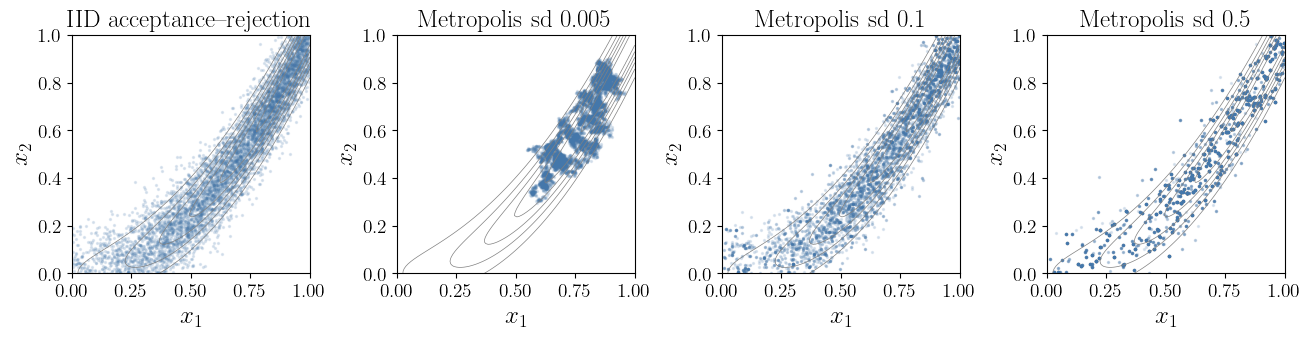

| Method | Accept | Retained | Mean x1 | Mean x2 |
|:---|---:|---:|---:|---:|
| IID acceptance--rejection | 12.6% | 6000 | 0.6526 | 0.4812 |
| Metropolis sd 0.005 | 96.7% | 6000 | 0.7700 | 0.6191 |
| Metropolis sd 0.1 | 47.6% | 6000 | 0.6601 | 0.4930 |
| Metropolis sd 0.5 | 8.8% | 6000 | 0.6645 | 0.5005 |
| Quadrature target | — | — | 0.6522 | 0.4797 |

AR: theoretical acceptance 0.126; expected proposals before batching 47728. QMCPy does not report the actual proposal count.
Each Metropolis run: 6999 proposals, including burn-in.


In [4]:
banana_n, banana_burn = 6000, 1000
banana_iid, banana_integral = banana_reference(banana_n)
banana_scales = [0.005, 0.1, 0.5]
banana_runs = [random_walk_nd(log_banana, [0.5, 0.5], banana_n + banana_burn, sd, rng)
               for sd in banana_scales]
banana_exact_mean = banana_mean()

grid = np.linspace(0, 1, 100)
grid1, grid2 = np.meshgrid(grid, grid)
points = np.column_stack([grid1.ravel(), grid2.ravel()])
density = np.exp(log_banana(points)).reshape(grid1.shape)
fig, axes = plt.subplots(1, 4, figsize=(13, 3.6), constrained_layout=True)
clouds = [banana_iid] + [r['states'][banana_burn:] for r in banana_runs]
labels = ['IID acceptance--rejection'] + [f'Metropolis sd {sd:g}' for sd in banana_scales]
for ax, values, label in zip(axes, clouds, labels):
    ax.contour(grid1, grid2, density, levels=7, colors='gray', linewidths=0.5)
    ax.scatter(values[:,0], values[:,1], s=2, color=colors['blue'], alpha=0.15)
    ax.set(xlabel='$x_1$', ylabel='$x_2$', title=label, xlim=(0,1), ylim=(0,1), aspect='equal')
plt.show()
rows = ['| Method | Accept | Retained | Mean x1 | Mean x2 |', '|:---|---:|---:|---:|---:|']
for label, values, rate in zip(labels, clouds, [banana_integral]+[r['acceptance'] for r in banana_runs]):
    avg = values.mean(axis=0)
    rows.append(f'| {label} | {rate:.1%} | {len(values)} | {avg[0]:.4f} | {avg[1]:.4f} |')
rows.append(f'| Quadrature target | — | — | {banana_exact_mean[0]:.4f} | {banana_exact_mean[1]:.4f} |')
display(Markdown('\n'.join(rows)))
print(f'AR: theoretical acceptance {banana_integral:.3f}; expected proposals before batching '
      f'{banana_n/banana_integral:.0f}. QMCPy does not report the actual proposal count.')
print(f'Each Metropolis run: {banana_n + banana_burn - 1} proposals, including burn-in.')


### What the comparison establishes

Acceptance–rejection returns IID target samples; Metropolis returns dependent states
and can explore poorly at a small proposal scale. A high local acceptance rate does
not compensate for slow travel along the ridge. The two acceptance percentages have
different meanings: AR's value here is theoretical, while the Metropolis values are
observed fractions of accepted moves.

The reference is a random sample, not exact ground truth. Quadrature supplies an
independent mean check. The [Discrepancy notebook](../performance/Discrepancy.ipynb)
compares these entire point clouds using kernels, including both the empirical and
off-diagonal MMD formulas from 2025.

**Try:** compare different starting points, run lengths, and proposal scales before
claiming one sampler is more efficient.

## Nearby and separated modes

### Experiment controls

Change `separation`, `proposal_sd`, `n`, or `burn`, then rerun the cells below.
`center` is the midpoint of the separated experiment's two component means.
`n` counts all states, including $X_0$; `burn` discards that many initial states
only when computing summaries. Traces show the entire run.

Start two independent runs at opposite component means. The midpoint divides
left and right **regions**, not latent component labels. Its exact target
probability is evaluated with the mixture CDF.

In [5]:
n = 12000
burn = 1500
separation = 10.0
center = 0.0
proposal_sd = 1.4

if not 0 <= burn < n - 1:
    raise ValueError("Require 0 <= burn < n - 1")
nearby = make_target((-2.2, 1.4))
separated = make_target((center - separation / 2, center + separation / 2))
experiments = {}
for name, target in [("Nearby modes", nearby), ("Separated modes", separated)]:
    runs = [random_walk(target, x0, n, proposal_sd, rng) for x0 in target['means']]
    experiments[name] = (target, runs)

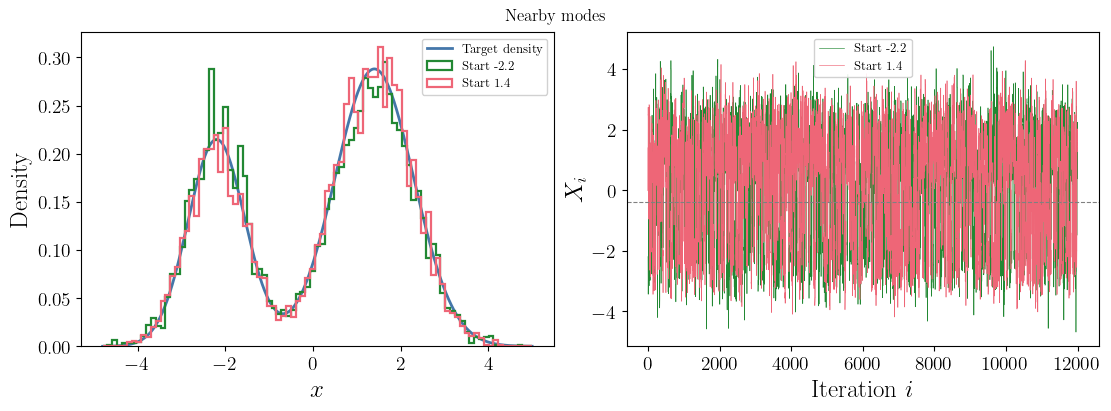

| Run | Accept | Crossings | Sample mean | Left-region fraction |
|:---|---:|---:|---:|---:|
| Start -2.2 | 61.3% | 899 | 0.034 | 0.394 |
| Start 1.4 | 61.3% | 902 | 0.151 | 0.358 |
| Target | — | — | 0.140 | 0.364 |

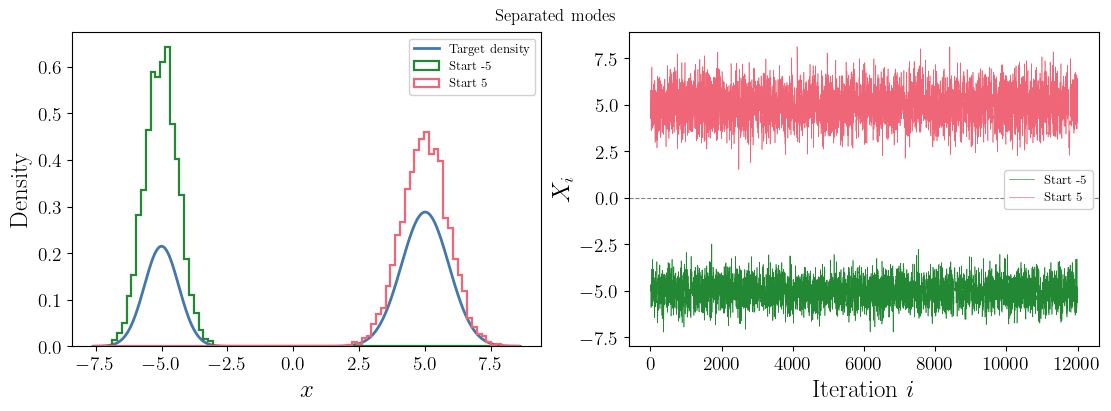

| Run | Accept | Crossings | Sample mean | Left-region fraction |
|:---|---:|---:|---:|---:|
| Start -5 | 47.4% | 0 | -5.016 | 1.000 |
| Start 5 | 58.3% | 0 | 4.993 | 0.000 |
| Target | — | — | 1.500 | 0.350 |

In [6]:
def show_runs(target, runs, labels, title, burn_ins=None, evaluation_scales=None):
    burn_ins = [burn]*len(runs) if burn_ins is None else burn_ins
    scales = [1]*len(runs) if evaluation_scales is None else evaluation_scales
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    grid = np.linspace(target['means'][0] - 4 * sds[0], target['means'][1] + 4 * sds[1], 900)
    axes[0].plot(grid, np.exp(target['log_density'](grid)), color=colors['blue'], lw=2,
                 label="Target density")
    edges = np.linspace(grid[0], grid[-1], 90)
    palette = [colors['green'], colors['red'], colors['purple']]
    for run, label, color, discard, scale in zip(runs, labels, palette, burn_ins, scales):
        states = run['states']
        axes[0].hist(states[discard:], bins=edges, density=True, histtype='step',
                     lw=1.6, color=color, label=label)
        axes[1].plot((np.arange(len(states))+1)*scale if evaluation_scales is not None else np.arange(len(states)), states, lw=0.45, color=color, label=label)
    axes[1].axhline(target['boundary'], color='gray', ls='--', lw=0.8)
    axes[0].set(xlabel="$x$", ylabel="Density")
    axes[1].set(xlabel="Target evaluations" if evaluation_scales is not None else "Iteration $i$", ylabel="$X_i$")
    for ax in axes:
        ax.legend(fontsize=9, frameon=True, facecolor="white", framealpha=0.9)
    fig.suptitle(title)
    plt.show()

def summary_table(target, runs, labels):
    rows = ["| Run | Accept | Crossings | Sample mean | Left-region fraction |",
            "|:---|---:|---:|---:|---:|"]
    for label, run in zip(labels, runs):
        states = run['states']
        retained = states[burn:]
        crossings = np.count_nonzero(np.diff(states < target['boundary']))
        rows.append(f"| {label} | {run['acceptance']:.1%} | {crossings} | "
                    f"{retained.mean():.3f} | {np.mean(retained < target['boundary']):.3f} |")
    rows.append(f"| Target | — | — | {target['mean']:.3f} | "
                f"{target['cdf'](target['boundary']):.3f} |")
    display(Markdown('\n'.join(rows)))

for name, (target, runs) in experiments.items():
    labels = [f"Start {x0:g}" for x0 in target['means']]
    show_runs(target, runs, labels, name)
    summary_table(target, runs, labels)

### Read the plots before trusting the averages

- Compare each histogram with the **whole** target density. Each histogram has
  area one, so a trapped chain overrepresents the hump it visits.
- The separated runs can have moderate acceptance rates but few or no crossings.
  Acceptance within a hump does not establish exploration of both humps.
- A Gaussian random-walk proposal can jump any finite distance with positive
  probability. “Trapped” describes these finite runs, not an absolute inability
  to cross. Outcomes vary across reruns.
- Discarding more burn-in does not repair a chain that has never visited the other
  mode. Nor does simply pooling equal numbers from two trapped chains: that assigns
  about one half to each region, rather than this target's approximately $0.35/0.65$.

**Try:** reduce the separation to $4$, then increase it to $8$ and $10$, keeping
proposal scale fixed. Compare crossings, region fractions, and agreement between
starting states. Where does the first warning appear?

## Proposal scale and dependence

### Small, moderate, and large random-walk steps

For the separated target, compare proposal standard deviations $0.2$, $1.4$, and
$6$. A larger step can jump between humps but also proposes more low-density states.
There is no universal acceptance-rate target that establishes adequate mixing.

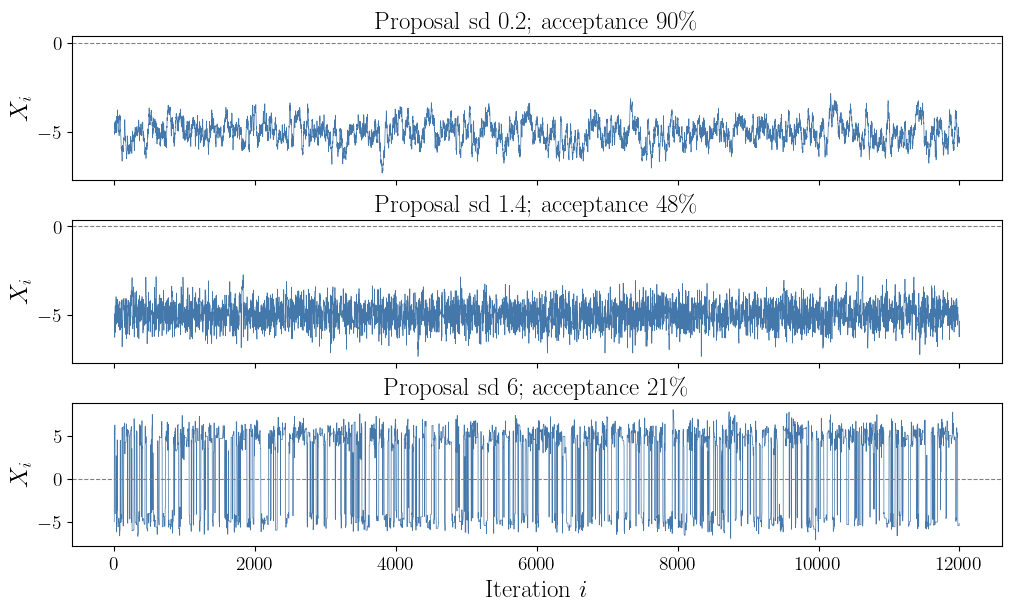

| Run | Accept | Crossings | Sample mean | Left-region fraction |
|:---|---:|---:|---:|---:|
| Proposal sd 0.2 | 90.3% | 0 | -5.036 | 1.000 |
| Proposal sd 1.4 | 48.0% | 0 | -4.992 | 1.000 |
| Proposal sd 6 | 20.6% | 488 | 1.467 | 0.356 |
| Target | — | — | 1.500 | 0.350 |

In [7]:
proposal_scales = [0.2, 1.4, 6.0]
scale_runs = [random_walk(separated, separated['means'][0], n, sd, rng)
              for sd in proposal_scales]
scale_labels = [f"Proposal sd {sd:g}" for sd in proposal_scales]
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True, constrained_layout=True)
for ax, run, label in zip(axes, scale_runs, scale_labels):
    ax.plot(np.arange(n), run['states'], color=colors['blue'], lw=0.5)
    ax.axhline(separated['boundary'], color='gray', ls='--', lw=0.8)
    ax.set(ylabel="$X_i$", title=f"{label}; acceptance {100 * run['acceptance']:.0f}" + r"\%")
axes[-1].set_xlabel("Iteration $i$")
plt.show()
summary_table(separated, scale_runs, scale_labels)

### Autocorrelation and effective sample information

For a stationary scalar output $Y_i=f(X_i)$ with summable correlations,
\begin{align*}
\operatorname{Var}\left(\frac1m\sum_{i=0}^{m-1}Y_i\right)
&\approx \frac{\operatorname{Var}(Y_0)}m\,	au_f,
&\tau_f&=1+2\sum_{k\ge1}\operatorname{Corr}(Y_0,Y_k).
\end{align*}
The effective sample size is approximately $m/\tau_f$. Here $m=n-\texttt{burn}$
is the retained sample size.

The code below uses a **within-chain heuristic**: estimate autocorrelations, then
sum positive successive pairs until the first nonpositive pair or the chosen lag
limit. This is a teaching diagnostic, not a convergence certificate or a production
ESS estimator. A trapped chain can appear to have many effective samples **within
one hump**. Check $f(x)=x$ and $f(x)=\mathbf1\{x<b\}$, where $b$ is the midpoint:
a constant region indicator has no estimable autocorrelation, not evidence of independence.

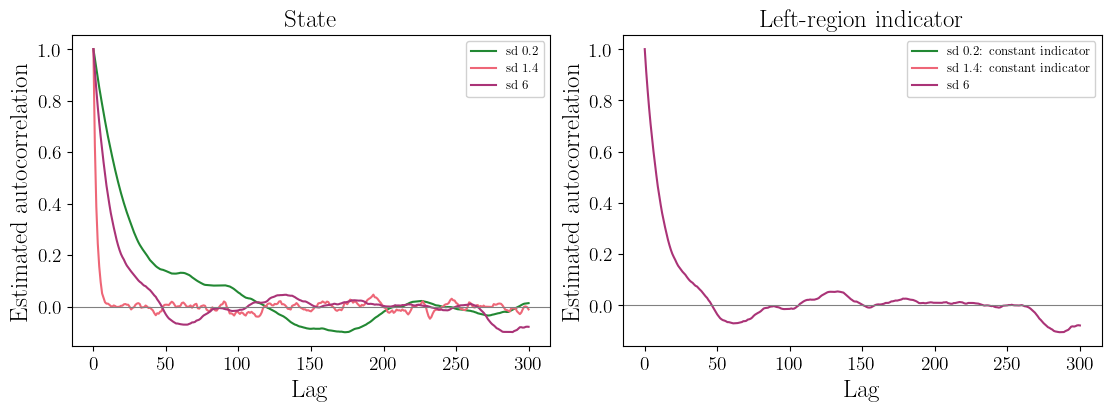

| Proposal sd | Within-chain ESS heuristic for x | For left-region indicator |
|---:|---:|---:|
| 0.2 | 201 | Not estimable |
| 1.4 | 2445 | Not estimable |
| 6 | 430 | 439 |

In [8]:
def acf(values, max_lag=300):
    values = np.asarray(values, dtype=float)
    centered = values - values.mean()
    if np.all(centered == 0):
        return np.full(min(max_lag + 1, len(values)), np.nan)
    fft_size = 1 << (2 * len(values) - 1).bit_length()
    transformed = np.fft.rfft(centered, n=fft_size)
    covariance = np.fft.irfft(transformed * transformed.conjugate(), n=fft_size)[:len(values)]
    return (covariance / covariance[0])[:max_lag + 1]

def ess_heuristic(values, max_lag=300):
    correlations = acf(values, max_lag)
    if not np.isfinite(correlations[0]):
        return np.nan
    # Pair lags (1,2), (3,4), ...; cap at m for this positively correlated example.
    total = 0.0
    for k in range(1, len(correlations) - 1, 2):
        pair = correlations[k] + correlations[k + 1]
        if pair <= 0:
            break
        total += pair
    return len(values) / max(1.0, 1 + 2 * total)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
rows = ["| Proposal sd | Within-chain ESS heuristic for x | For left-region indicator |",
        "|---:|---:|---:|"]
for sd, run, color in zip(proposal_scales, scale_runs, [colors['green'], colors['red'], colors['purple']]):
    values = run['states'][burn:]
    outputs = [values, (values < separated['boundary']).astype(float)]
    estimates = []
    for ax, output in zip(axes, outputs):
        correlations = acf(output)
        if np.isfinite(correlations[0]):
            ax.plot(np.arange(len(correlations)), correlations, color=color, label=f"sd {sd:g}")
        else:
            ax.plot([], [], color=color, label=f"sd {sd:g}: constant indicator")
        estimate = ess_heuristic(output)
        estimates.append(f"{estimate:.0f}" if np.isfinite(estimate) else "Not estimable")
    rows.append(f"| {sd:g} | {estimates[0]} | {estimates[1]} |")
for ax, title in zip(axes, ["State", "Left-region indicator"]):
    ax.set(xlabel="Lag", ylabel="Estimated autocorrelation", title=title)
    ax.axhline(0, color='gray', lw=0.8)
    ax.legend(fontsize=9, frameon=True, facecolor="white", framealpha=0.9)
plt.show()
display(Markdown('\n'.join(rows)))

## A proposal that can reach both humps

### Independence Metropolis–Hastings

Try $Z\sim\operatorname{Norm}(c,6^2)$ independently of the current state, with
$c$ the midpoint of the means. This is a nonlocal proposal. It is **not** a
symmetric random-walk proposal: $q(z\mid x)=q(z)$ and $q(x\mid z)=q(x)$ are
generally different, so retain the Hastings correction $q(x)/q(z)$.

Changing the proposal does not guarantee success on every target. Here the known
mixture lets us check whether both region probabilities and the mean are represented.

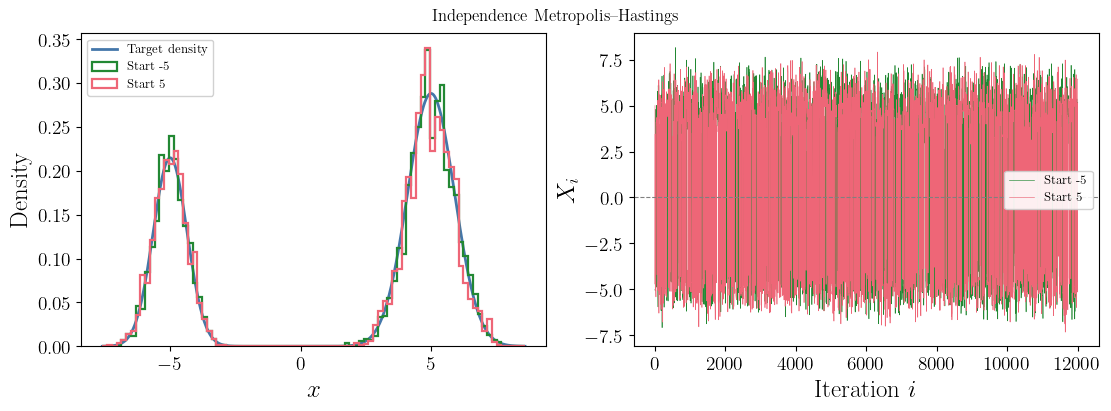

| Run | Accept | Crossings | Sample mean | Left-region fraction |
|:---|---:|---:|---:|---:|
| Start -5 | 22.9% | 1253 | 1.477 | 0.354 |
| Start 5 | 22.2% | 1258 | 1.362 | 0.363 |
| Target | — | — | 1.500 | 0.350 |

In [9]:
independence_sd = 6.0
independence_center = separated['boundary']
def independence_log_proposal(new, old):
    return -0.5 * ((new - independence_center) / independence_sd)**2  # constant cancels

independence_runs = [metropolis_hastings(
    separated['log_density'], x0, n,
    lambda x, rng: rng.normal(independence_center, independence_sd),
    independence_log_proposal, rng) for x0 in separated['means']]
labels = [f"Start {x0:g}" for x0 in separated['means']]
show_runs(separated, independence_runs, labels, "Independence Metropolis--Hastings")
summary_table(separated, independence_runs, labels)

### Running estimates and direct-sampling reference

Compare a trapped random walk, an independence chain, and direct IID mixture
samples. Plot the mean and left-region fraction against their exact values.
An apparently flat running estimate can be far from the target answer.

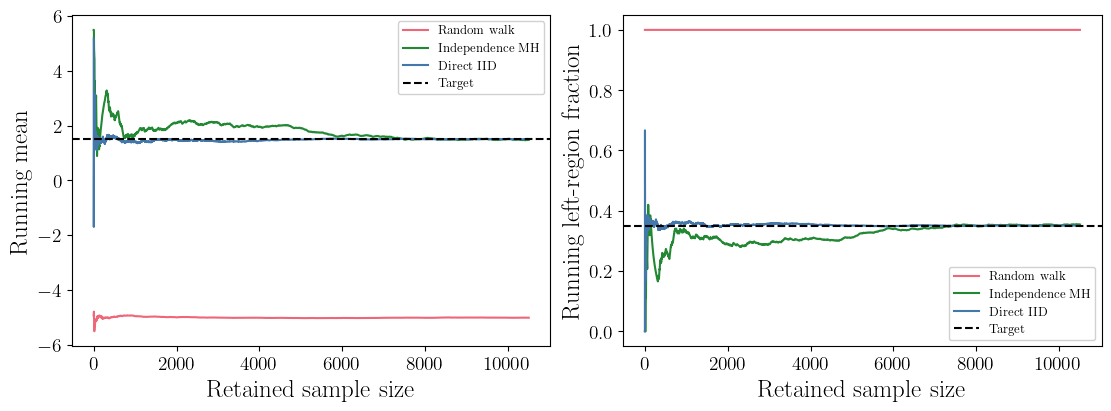

In [10]:
m = n - burn
components = rng.choice(2, size=m, p=weights)
iid = rng.normal(separated['means'][components], sds[components])
comparisons = [("Random walk", experiments['Separated modes'][1][0]['states'][burn:]),
               ("Independence MH", independence_runs[0]['states'][burn:]),
               ("Direct IID", iid)]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
counts = np.arange(1, m + 1)
for (label, values), color in zip(comparisons, [colors['red'], colors['green'], colors['blue']]):
    axes[0].plot(counts, np.cumsum(values) / counts, color=color, label=label)
    axes[1].plot(counts, np.cumsum(values < separated['boundary']) / counts, color=color, label=label)
axes[0].axhline(separated['mean'], color='black', ls='--', label="Target")
axes[1].axhline(separated['cdf'](separated['boundary']), color='black', ls='--', label="Target")
for ax, ylabel in zip(axes, ["Running mean", "Running left-region fraction"]):
    ax.set(xlabel="Retained sample size", ylabel=ylabel)
    ax.legend(fontsize=9, frameon=True, facecolor="white", framealpha=0.9)
plt.show()

## Parallel tempering: help the cold chain cross

### Flatten the whole target

For $1=\beta_0>\cdots>\beta_{R-1}>0$, let
\begin{align*}
\pi_{\beta_r}(x)&\propto\varrho_{\mathrm{tar}}(x)^{\beta_r}.
\end{align*}
The cold slot $\beta_0=1$ has the original target. Hotter replicas flatten both
humps and their intervening valley. Only the **cold-slot** samples represent the
original target; do not pool samples from different temperatures.

We temper the **entire target density**, including a prior when the target is a
posterior. Likelihood-only tempering is a different construction with a different
swap ratio. Every tempered density must be integrable; this Gaussian-mixture
example satisfies that condition for every positive $\beta$.

### Exchange states between temperatures

Each sweep first gives every replica a random-walk Metropolis update, then proposes
swaps of disjoint adjacent pairs. For adjacent slots $r,s$, the joint-target ratio is
\begin{align*}
\alpha_{\mathrm{swap}}
&=\min\left\{1,
\frac{\varrho_{\mathrm{tar}}(x_s)^{\beta_r}\varrho_{\mathrm{tar}}(x_r)^{\beta_s}}
{\varrho_{\mathrm{tar}}(x_r)^{\beta_r}\varrho_{\mathrm{tar}}(x_s)^{\beta_s}}\right\}\\
&=\min\left\{1,\exp\left[(\beta_r-\beta_s)
(\log\varrho_{\mathrm{tar}}(x_s)-\log\varrho_{\mathrm{tar}}(x_r))\right]\right\}.
\end{align*}
The unknown normalizing constants cancel. Accepted swaps let the cold slot inherit
states reached by hot replicas. Local updates and swap steps preserve the joint
product target. Their composition preserves it too.

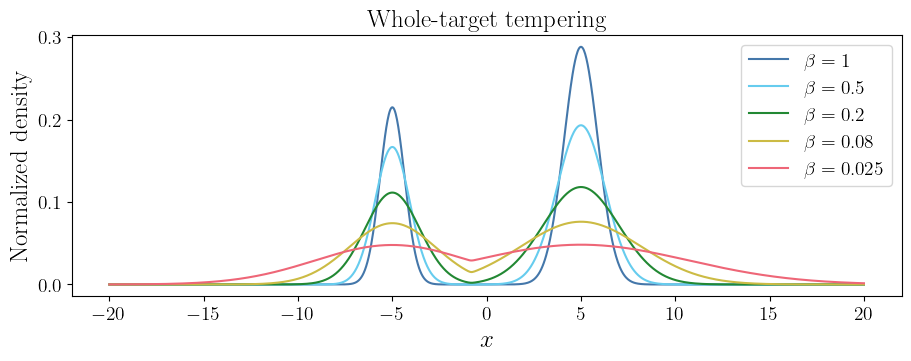

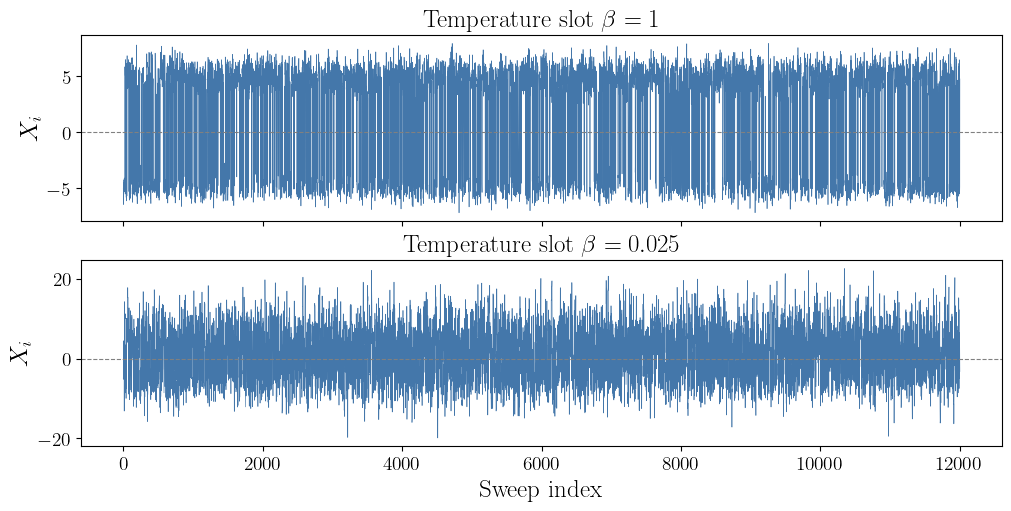

| Adjacent betas | Accepted swaps / attempted |
|:---|---:|
| 1, 0.5 | 4687 / 6000 |
| 0.5, 0.2 | 4311 / 5999 |
| 0.2, 0.08 | 4437 / 6000 |
| 0.08, 0.025 | 4368 / 5999 |

In [11]:
from scipy.integrate import quad
betas = np.array([1.0, 0.5, 0.2, 0.08, 0.025])
pt_scales = proposal_sd / np.sqrt(betas)
fig, ax = plt.subplots(figsize=(9, 3.5), constrained_layout=True)
temper_grid = np.linspace(-20, 20, 1200)
for beta in betas:
    normalizer = quad(lambda x: np.exp(beta * separated['log_density'](x)),
                      -np.inf, np.inf, epsabs=1e-9)[0]
    ax.plot(temper_grid, np.exp(beta*separated['log_density'](temper_grid))/normalizer,
            label=rf'$\beta={beta:g}$')
ax.set(xlabel='$x$', ylabel='Normalized density', title='Whole-target tempering')
ax.legend(frameon=True)
plt.show()

# Every replica begins in the left hump: exchanges must be earned by exploration.
pt_result = parallel_tempering(separated['log_density'],
    np.full(len(betas), separated['means'][0]), betas, n, pt_scales, rng)
pt_cold = pt_result['states'][:,0]
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, constrained_layout=True)
for ax, j in zip(axes, [0, len(betas)-1]):
    ax.plot(np.arange(n), pt_result['states'][:,j], lw=0.45, color=colors['blue'])
    ax.axhline(separated['boundary'], color='gray', ls='--', lw=0.8)
    ax.set(ylabel='$X_i$', title=rf'Temperature slot $\beta={betas[j]:g}$')
axes[-1].set_xlabel('Sweep index')
plt.show()
display(Markdown('| Adjacent betas | Accepted swaps / attempted |\n|:---|---:|\n'+'\n'.join(
    f'| {betas[j]:g}, {betas[j+1]:g} | {pt_result["swaps"][j]} / {pt_result["swap_attempts"][j]} |'
    for j in range(len(betas)-1))))


### Compare against the computational budget

One tempering sweep proposes $R$ local moves. Counting cached log-target evaluations,
our tempering run costs $Rn$, including initialization; swaps reuse those values.
Give a plain random walk that same evaluation budget. Keep its burn-in proportional
to the extra number of iterations. Compare target means, region proportions, and
crossings; equal numbers of plotted samples alone would conceal tempering's cost.

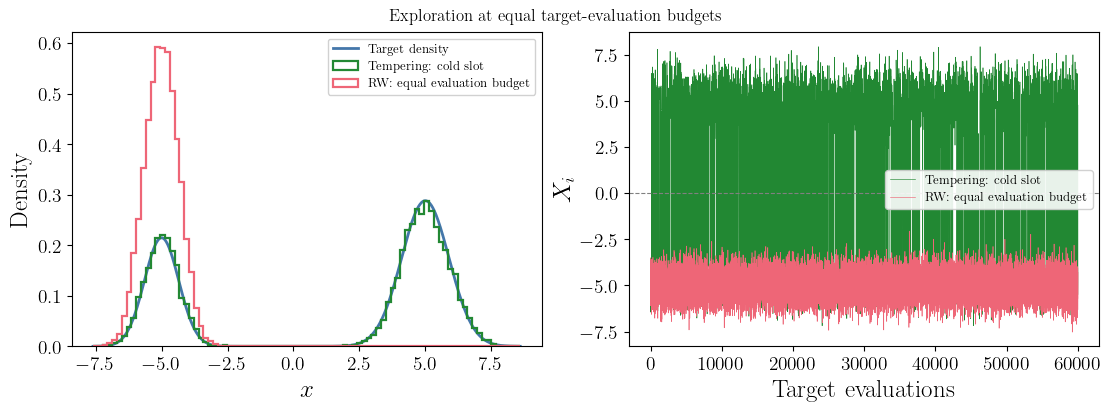

| Method | Target evaluations | Retained mean | Left fraction | Crossings after burn |
|:---|---:|---:|---:|---:|
| Tempering cold | 60000 | 1.368 | 0.364 | 1955 |
| Plain random walk | 60000 | -5.000 | 1.000 | 0 |
| Target | — | 1.500 | 0.350 | — |

In [12]:
budget_n = pt_result['evaluations']
budget_burn = len(betas)*burn
budget_rw = random_walk(separated, separated['means'][0], budget_n, proposal_sd, rng)
comparison_runs = [dict(states=pt_cold, acceptance=pt_result['acceptance'][0]),
                   dict(states=budget_rw['states'], acceptance=budget_rw['acceptance'])]
show_runs(separated, comparison_runs, ['Tempering: cold slot', 'RW: equal evaluation budget'],
          'Exploration at equal target-evaluation budgets',
          burn_ins=[burn, budget_burn], evaluation_scales=[len(betas), 1])
rows=['| Method | Target evaluations | Retained mean | Left fraction | Crossings after burn |',
      '|:---|---:|---:|---:|---:|']
for label, values in [('Tempering cold',pt_cold[burn:]),
                      ('Plain random walk',budget_rw['states'][budget_burn:])]:
    rows.append(f'| {label} | {budget_n} | {values.mean():.3f} | '
                f'{np.mean(values<separated["boundary"]):.3f} | '
                f'{np.count_nonzero(np.diff(values<separated["boundary"]))} |')
rows.append(f'| Target | — | {separated["mean"]:.3f} | {separated["cdf"](separated["boundary"]):.3f} | — |')
display(Markdown('\n'.join(rows)))


A successful cold chain should visit both humps in approximately the correct
proportions, not merely alternate between them. Swaps alone are not proof: replicas
also need adequate exploration. Change the temperature ladder, number of sweeps, and
proposal scales, and repeat the experiment.

Here a broad independence proposal is another useful remedy because we already know
where both humps lie. Tempering is not automatically the cheapest solution. Compare
both approaches before choosing one.

## Experiments and conclusions

1. Increase `n` without changing the small random-walk proposal. Does either chain
   cross the midpoint? Explain why a longer run may still be inadequate.
2. Increase `burn`. Does discarding initial states repair missing a mode?
3. Compare several fresh runs at the same settings. How much do the answers depend
   on the starting hump?
4. Compare a larger random-walk proposal with the independence proposal. Which
   explores both modes more effectively at these settings? Include region fractions,
   traces, and estimation error, not acceptance rate alone.
5. Explain why equal pooling of two trapped chains is not a general remedy.

**Takeaway:** target invariance describes the transition's mathematical design;
finite-run exploration must still be investigated. Multiple dispersed starts expose
some failures that a single histogram or within-chain diagnostic can hide.

The tempering comparison above does not replace checking that the cold chain
explores the original target in the correct proportions.

In [13]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(f"Total execution time for this notebook is "
      f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec.")


Total execution time for this notebook is 0 min 5.2 sec.
